# Linear transport equation

We consider the continuous-time quantum walk on graphs, as described by 
$$i \frac{d}{dt} \psi = H \psi,$$
where $H$ is the adjacency matrix of one-dimensional chain graphs.


## Antiferromagnetic encoding of chains (toy model)

To simulate quantum walk on Rydberg atom systems, we employ the antiferromagnetic encoding. Consider an $r$-qubit quantum Hamiltonian:
$$H_Z = Z_1 + (-1)^r Z_r + \sum^{r-1}_{j=1}Z_j Z_{j+1}.$$

This Hamiltonian has a $(r+1)$-fold degenerate ground-energy subspace, and the spectral gap (i.e., difference between the first and second energy levels) is 4. We use the $(r+1)$ ground states of $H_Z$ to represent the nodes of a chain graph. We use "0101...010" when $n$ is odd ("10...1010" when $n$ is even) to represent node "1" on the graph. Then, for any $k \in \{2,3,...,r+1\}$, the node "k" is represented by flipping the $(k-1)$-th bit (starting from the left) of the bitstring representing the $(k-1)$-th node.

For example, if we take $r = 5$, the nodes $\{1,2,3,4,5,6\}$ are mapped to $\{"01010","01011","01001","01101","00101","10101"\}$.

It is noted that, when restricting to the ground-energy space of $H_Z$, the "sum of X" operator reduces to the adjacency matrix of the 1D chain graph with $(r+1)$ nodes. 

## Antiferromagnetic encoding of chains (Rydberg systems)

In order to derive the detuning values for the actual Rydberg system, it may be convenient to first consider $Z_j Z_k$ interactions between all pairs of qubits, since the Rydberg atoms has $\hat{n}_j \hat{n}_k$ interactions between all qubits. When the qubits are placed on a straight line and the distance between two adjacent qubits is $R$, the Rydberg (van de Waals) interaction between qubits $j$ and $k$, where $j<k$, is given by $\frac{C_6}{R^6 |k-j|^6} \hat{n}_j \hat{n}_k $. Therefore, let us first consider the Hamiltonian
$$ H_Z^{(1)} = \sum_{j<k} \frac{C_6}{R^6 |j-k|^6} Z_j Z_k.$$
The Hamiltonian is similar to the sum of $Z_j Z_{j+1}$ terms in the above "toy model," but with small additional $Z_j Z_k$ terms for $|j-k|\geq 2$.

To compute the appropriate detunings, it suffices to choose coefficients of $Z_j$ such that the energy of each pair of bitstrings with Hamming distance 1 are equal. Suppose we add 1-site Pauli-z terms $\sum_{j=1}^{r} a_j Z_j$, where $a_j$ are coefficients to be determined. When considering the first two bitstrings "0101...010" and "1101...010", the energy difference is equal to $2\left(a_1 + \frac{C_6}{R^6}\sum_{j=1}^{r-1} \frac{(-1)^{j}}{j^6}\right)$, which implies we should choose $a_1 = \frac{C_6}{R^6} \sum_{j=1}^{r-1} \frac{(-1)^{j+1}}{j^6}$. In general for $k=1,\dots,r-1$, the energy difference between the $k$th node and the $(k+1)$th node is equal to $2\left((-1)^{k+1} a_{k} + \frac{C_6}{R^6} \sum_{j=k}^{r-k} \frac{(-1)^{j}}{j^6}\right)$, so we must choose $a_{k} = \frac{C_6}{R^6}\sum_{j=k}^{r+1-k} \frac{(-1)^{j+k}}{j^6}$.

We can convert from $Z_j$ to $\hat{n}_j=(I - Z_j)/2$, but we can also directly use the same approach to compute the coefficients in terms of $\hat{n}_j$. In the Rydberg Hamiltonian, the sum of 1-site Pauli-z's is given as $-\sum_j \Delta_j \hat{n}_j$. Comparing the energies for the $k$th node and the $(k+1)$th node, we get $\frac{\Delta_{k}}{C_6 / R^6} = \sum_{j=1}^{\lfloor (r+1-k)/2 \rfloor} \frac{1}{(2j-1)^6} + \sum_{j=1}^{\lfloor (k-1)/2 \rfloor} \frac{1}{(2j)^6}$ whenever $k$ is odd, and $\frac{\Delta_{k}}{C_6 / R^6} = \sum_{j=1}^{\lfloor (r-k)/2 \rfloor} \frac{1}{(2j)^6} + \sum_{j=1}^{\lfloor (k+1)/2 \rfloor} \frac{1}{(2j-1)^6}$ whenever $k$ is even.

More generally, if we want to put the atoms in a more deformed/perturbed chain structure (in which adjacent qubits may not be equally spaced), the detunings needed to align the eigenvalues are as follows: $\frac{\Delta_{k}}{C_6} = \sum_{j=1}^{\lfloor (r+1-k)/2 \rfloor} \frac{1}{d_{k,k+(2j-1)}^6} + \sum_{j=1}^{\lfloor (k-1)/2 \rfloor} \frac{1}{d_{k,k-(2j)}^6}$ when $k$ is odd, and $\frac{\Delta_{k}}{C_6} = \sum_{j=1}^{\lfloor (r-k)/2 \rfloor} \frac{1}{d_{k,k+(2j)}^6} + \sum_{j=1}^{\lfloor (k+1)/2 \rfloor} \frac{1}{d_{k,k-(2j-1)}^6}$ when $k$ is even, where $d_{j,k}=d_{k,j}$ is the distance between qubits $j$ and $k$.

In [1]:
function get_detuning_arbitrary(r::Integer, positions::Matrix{Float64}, C6::Float64)
    Δ = zeros(r)
    for k in 1:r
        if isodd(k)
            for j in 1:(r+1-k)/2
                Δ[k] += 1 / norm(positions[k,:] - positions[Integer(k+(2*j-1)),:])^6
            end
            for j in 1:(k-1)/2
                Δ[k] += 1 / norm(positions[k,:] - positions[Integer(k-2*j),:])^6
            end
        else
            for j in 1:(r-k)/2
                Δ[k] += 1 / norm(positions[k,:] - positions[Integer(k+2*j),:])^6
            end
            for j in 1:(k+1)/2
                Δ[k] += 1 / norm(positions[k,:] - positions[Integer(k-(2*j-1)),:])^6
            end
        end
    end
    return C6 * Δ
end

get_detuning_arbitrary (generic function with 1 method)

In [2]:
function get_detuning_equal_spacing(r::Integer, R::Float64, C6::Float64)
    Δ = zeros(r)
    for k in 1:r
        if isodd(k)
            for j in 1:(r+1-k)/2
                Δ[k] += 1 / (2j-1)^6
            end
            for j in 1:(k-1)/2
                Δ[k] += 1 / (2j)^6
            end
        else
            for j in 1:(r-k)/2
                Δ[k] += 1 / (2j)^6
            end
            for j in 1:(k+1)/2
                Δ[k] += 1 / (2j-1)^6
            end
        end
    end
    return C6 * Δ / R^6
end

get_detuning_equal_spacing (generic function with 1 method)

In [3]:
function get_phase(r::Integer)
    ϕ = zeros(r)
    for k in 1:r
        if isodd(k)
            ϕ[k] = 3 * pi / 2
        else
            ϕ[k] = pi / 2
        end
    end
    return ϕ
end

get_phase (generic function with 1 method)

## Experiment setup on QuEra (Rydberg systems)

Introducing the number operator $\hat{n}_j = \frac{1}{2}(I-Z_j)$, so $Z_j = I - 2\hat{n}_j$. Therefore, the penalty Hamiltonian becomes:
$$H_Z = 4 \sum^{r-1}_{j=1}\hat{n}_j\hat{n}_{j+1} - 4 \left(\sum^{r-1}_{j=1}\hat{n}_j + \frac{1+(-1)^r}{2}\hat{n}_r \right) + [r+(-1)^r]I.$$
The global phase $[r+(-1)^r]I$ can be ignored without consequence to quantum simulation. We also normalize the penalty Hamiltonian by a factor of $4$ so that the Hamiltonian now has unital spectral gap, i.e., 
$$\tilde{H} = \sum^{r-1}_{j=1}\hat{n}_j\hat{n}_{j+1} - \left(\sum^{r-1}_{j=1}\hat{n}_j + \frac{1+(-1)^r}{2}\hat{n}_r \right).$$

To map the above penalty Hamiltonian $\tilde{H}$ to physical qubits on the QuEra machine, we consider a chain lattice of atoms: all $r$ atoms are equally separated and they are aligned on a straight line. Suppose the distance between two adjacent qubits is $R$, then the Rydberg interaction between two adjacent qubits is 
$$V_{j,j+1} = \frac{C_6}{R^6}\hat{n}_j\hat{n}_{j+1},$$
where the coefficient $C_6 = 2\pi \times 862690$ MHz$\cdot \mu m^6$. Although the interaction between two non-adjacent qubits still exists, it is at least $1/64$ times smaller than the adjacent interactions. Ignoring the non-adjacent Rydberg interaction terms, we obtain the effective Hamiltonian of the Rydberg system:
$$\frac{H}{\hbar} \approx \frac{\Omega}{2}\sum^r_{j=1}X_j + \frac{C_6}{R^6}\sum^{r-1}_{j=1}\hat{n}_j\hat{n}_{j+1} - \sum^r_{j=1}\Delta_j \hat{n}_j,$$
where $\Omega$ is the (global) Rabi frequency ranging from $-8\pi$ to $8\pi$ MHz, $R$ is the distance between two adjacent qubits (in the unit of $\mu m$), and $\Delta_j$ is (local) detuning ranging from $-40\pi$ to $80\pi$ MHz. The maximal Rydberg evolution time is $T_1 = 4 \mu s$. 

Comparing the effective Rydberg system Hamiltonian to the penalty Hamiltonian, we must set: $\Delta_j = C_6/R^6$ for $j = 1,2,...,r-1$, $\Delta_r = C_6/R^6$ for even $r$ and $\Delta_r = 0$ for odd $r$. Note that $\Delta_j \le 250$ MHz, then the parameter $R$ is such that $R > \left(C_6/\Delta_{max} \right)^{1/6} \approx 5.28 \mu m$.

## Parameters factsheet

The following parameters are used to simulate quantum walk on a $9$-node chain graph for a time 
$$T = (\Omega/2)\times t_s.$$

In [6]:
using Bloqade

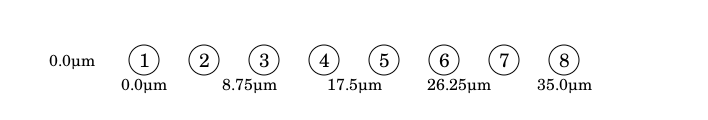

In [18]:
C6 = 862690*2*pi # Rydberg interaction constanct / MHz⋅μm^6
r = 8 # Number of qubits
R = 5.0 # Lattice scale / μm
ϕ = get_phase(r) # laser phase / radians
Ω = 10.0 # (Global) Rabi frequency / MHz
Δ = get_detuning_equal_spacing(r, R, C6) # (Global) detuning / MHz
ts = 2.0 # Simulation time / μs

# mapping = [bit"0101010", bit"0101011", bit"0101001", bit"0101101",
#            bit"0100101", bit"0110101", bit"0010101", bit"1010101"]

chain = ChainLattice()
atoms = generate_sites(chain, r; scale = R)

In [19]:
chain_indices = Array{Int64}(undef, r+1)

if isodd(r)
    val = Int(2 * (4 ^ ((r-1)/2) - 1) / 3)
else
    val = Int(2 * (4 ^ (r/2) - 1) / 3)
end
chain_indices[1] = Int(val)

for i in 1:r
    val += Int((-2) ^ (i-1))
    chain_indices[i+1] = Int(val)
end

In [20]:
# Arbitrary chain-like configuration

# atoms = AtomList([(R * k + (-0.5)^k, sin(k) + 0.1 * k^2 + (-1)^k) for k in 1:r])

In [21]:
# atom_coordinates_matrix = hcat(first.(atoms), last.(atoms))

# Δ = get_detuning_arbitrary(r, atom_coordinates_matrix, C6)

In [22]:
h_walk = rydberg_h(atoms; C=C6, Δ=Δ, Ω=Ω, ϕ=ϕ) # quantum walk Hamiltonian
H0 = complex(zeros(r+1,r+1))
h_mat = mat(h_walk)

for ii in 1:r+1
    for jj in 1:r+1
        H0[ii,jj] = h_mat[chain_indices[ii]+1,chain_indices[jj]+1]
    end
end

print("The restriction of system Hamiltonian to the ground-energy subspace:\n")
print("(Note that global phase does not effect quantum evolution)")
display(H0)

The restriction of system Hamiltonian to the ground-energy subspace:
(Note that global phase does not effect quantum evolution)

9×9 Matrix{ComplexF64}:
     -1389.11+0.0im  -9.18485e-16-5.0im  …          0.0+0.0im
 -9.18485e-16+5.0im      -1389.11+0.0im             0.0+0.0im
          0.0+0.0im   3.06162e-16+5.0im             0.0+0.0im
          0.0+0.0im           0.0+0.0im             0.0+0.0im
          0.0+0.0im           0.0+0.0im             0.0+0.0im
          0.0+0.0im           0.0+0.0im  …          0.0+0.0im
          0.0+0.0im           0.0+0.0im             0.0+0.0im
          0.0+0.0im           0.0+0.0im     3.06162e-16-5.0im
          0.0+0.0im           0.0+0.0im        -1389.11+0.0im

In [23]:
# Emulation
# The quantum walk start from some initial node
initial_node = 4
# bitstring array is reversed compared to literal bitstring
reg = product_state([Int(floor(chain_indices[initial_node] / 2^(i-1)) % 2) for i in 1:r]) # create fullspace register
walk = SchrodingerProblem(reg, ts, h_walk)
emulate!(walk)

SchrodingerProblem:
  register info:
    type: ArrayReg{2, ComplexF64, Matrix{ComplexF64}}
    storage size: 8 bytes

  time span (μs): (0.0, 2.0)

  equation: 
    storage size: 55.984 KiB
    expression:
nqubits: 8
+
├─ [+] ∑ 2π ⋅ 8.627e5.0/|r_i-r_j|^6 n_i n_j
├─ [+] 2π ⋅ 0.796 ⋅ ∑ e^{ϕ_i ⋅ im} |0⟩⟨1| + e^{-ϕ_i ⋅ im} |1⟩⟨0|
└─ [-] ∑ Δ_i ⋅ n_i


  options:
    save_everystep: false
    save_start: false
    save_on: false
    dense: false


In [24]:
# Extract final quantum distribution from raw samples/state-vectors 
raw_dist_quera = reg |> probs
select_dist_quera = zeros(r+1)

for jj in 1:r+1
    select_dist_quera[jj] = raw_dist_quera[chain_indices[jj]+1]
end

print("The leakage to the high-energy subspace is $(1-sum(select_dist_quera)).\n")
print("The final quantum distribution (restricted to the low-energy subspace) is:")
display(select_dist_quera)

The leakage to the high-energy subspace is -0.0007810231317977312.
The final quantum distribution (restricted to the low-energy subspace) is:

9-element Vector{Float64}:
 0.018573959353452643
 0.13118163478419673
 0.0004178940361565337
 0.45642234777820956
 0.012420554688408617
 0.06321491557800947
 0.05245764238694667
 0.23311067323787193
 0.03298140128854547

In [25]:
using LinearAlgebra
using SparseArrays
using ExpmV
using Plots
using DifferentialEquations

## Classical simulation of quantum walk on 1D chains

In [26]:

function chain_walk_predict!(dist_predict::AbstractArray, N::Integer, T::AbstractFloat, node::Integer)
    # dist_predict: a buffer for the predicted distribution
    # N:            number of nodes on the 1D ring
    # T:            runtime of continuous-time quantum walk
    # node:         the starting node of the quantum walk
    
    a = ones(N-1)
    b = zeros(N)
    A = -1im * Tridiagonal(-a,b,a)
    A = sparse(A)
    
    if node > N
        print("The node arg must be no more than N!")
        return
    else
        u0 = zeros(ComplexF64, N)
        u0[node] = 1
        wave = expmv(T, -1im * A, u0) # ExpmV only works with sparse A

        for jj in 1:N
            amplitude = wave[jj]
            dist_predict[jj] = abs2(amplitude)
        end

        return 
    end
end

chain_walk_predict! (generic function with 1 method)

### Visualization 1: final quantum distribution

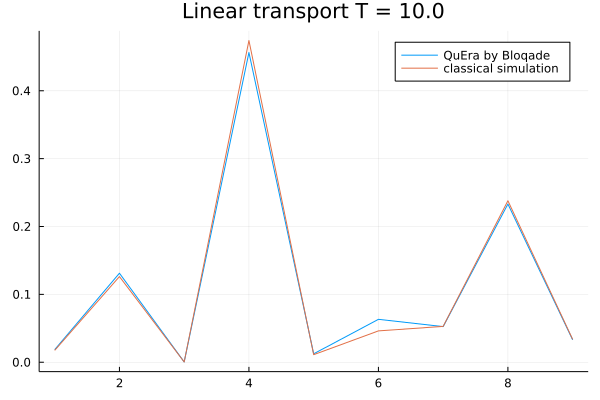

In [27]:
N = r + 1
T = Ω / 2 * ts
dist_predict = Array{Float64}(undef, N)
chain_walk_predict!(dist_predict, N, T, initial_node) # predict quantum walk dist by classical simulation

plot(select_dist_quera, label="QuEra by Bloqade", title="Linear transport T = $T")
plot!(dist_predict, label="classical simulation")

### Visualization 2: dynamical evolution

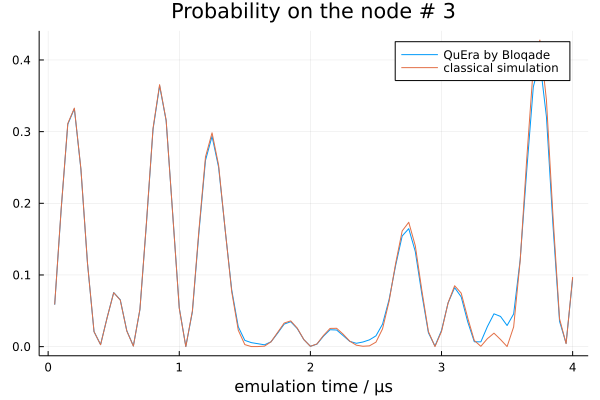

In [28]:
node = 3

num_frames = 80
times = LinRange(0.05, 4.0, num_frames) 
quera_results = zeros(num_frames)
predict_results = zeros(num_frames)

for frame in 1:num_frames
    ts = times[frame]
    T = Ω / 2 * ts

    # Quantum emulation
    reg = product_state([Int(floor(chain_indices[initial_node] / 2^(i-1)) % 2) for i in 1:r]) # create fullspace register
    walk = SchrodingerProblem(reg, ts, h_walk)
    emulate!(walk)
    raw_dist_quera = reg |> probs
    quera_results[frame] = raw_dist_quera[chain_indices[node]+1]

    # Classical simulation
    dist_predict = Array{Float64}(undef, N)
    chain_walk_predict!(dist_predict, N, T, initial_node)
    predict_results[frame] = dist_predict[node]
end

plot(times, quera_results, label="QuEra by Bloqade", title="Probability on the node # $node")
plot!(times, predict_results, label="classical simulation")
xlabel!("emulation time / μs")

# State preparation